<a href="https://colab.research.google.com/github/aishah1803/Hand_Hygeine_classifier/blob/yolov26_experiment/Hand_Hygiene_Classifier_YOLOv26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: False
GPU count: 0


In [4]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
!pip -q install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.3 MB/s eta 0:00:00


In [6]:
!ls -la "/content/drive/MyDrive/hand_hygeine_project/dataset"

total 9
-rw------- 1 root root  122 Apr 13 19:17 data.yaml
drwx------ 2 root root 4096 Apr  9 12:06 images
drwx------ 2 root root 4096 Apr  9 12:06 labels


In [7]:
DATASET_DIR = "/content/drive/MyDrive/hand_hygeine_project/dataset"

yaml_text = f"""\
path: {DATASET_DIR}
train: images/train
val: images/train
names:
  0: gel
  1: hand
"""
open(f"{DATASET_DIR}/data.yaml", "w").write(yaml_text)
print("Updated class names in data.yaml")

Updated class names in data.yaml


In [8]:
from ultralytics import YOLO

DATA_YAML = "/content/drive/MyDrive/hand_hygeine_project/dataset_split/data.yaml"

model = YOLO("yolo26n-seg.pt")   # smaller, faster
model.train(
    data=DATA_YAML,
    imgsz=320,   # smaller image size
    epochs=60,   # fewer epochs
    batch=2,
    device="cpu",
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/hand_hygeine_project/dataset_split/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e1093847e00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04104

In [9]:
model.val(data=DATA_YAML, imgsz=320, device="cpu")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
YOLO26n-seg summary (fused): 139 layers, 2,689,274 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 512.4±86.2 MB/s, size: 6888.1 KB)
val: Scanning /content/drive/MyDrive/hand_hygeine_project/dataset_split/labels/val.cache... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 1.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.9s/it 1.9s
                   all          5         21      0.219      0.431       0.33      0.275       0.49        0.2      0.301      0.197
                   gel          5         16     0.0549     0.0625     0.0161    0.00393          0          0     0.0147     0.0038
                  hand          5          5      0.383        0.8      0.644      0.547      0.981        0.4      0.587       0.39
Speed: 0.3ms preprocess,

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e10805dee70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04104

In [10]:
!cp /content/runs/segment/train2/weights/best.pt "/content/drive/MyDrive/hand_hygeine_project/best_split_fast.pt"

cp: cannot stat '/content/runs/segment/train2/weights/best.pt': No such file or directory


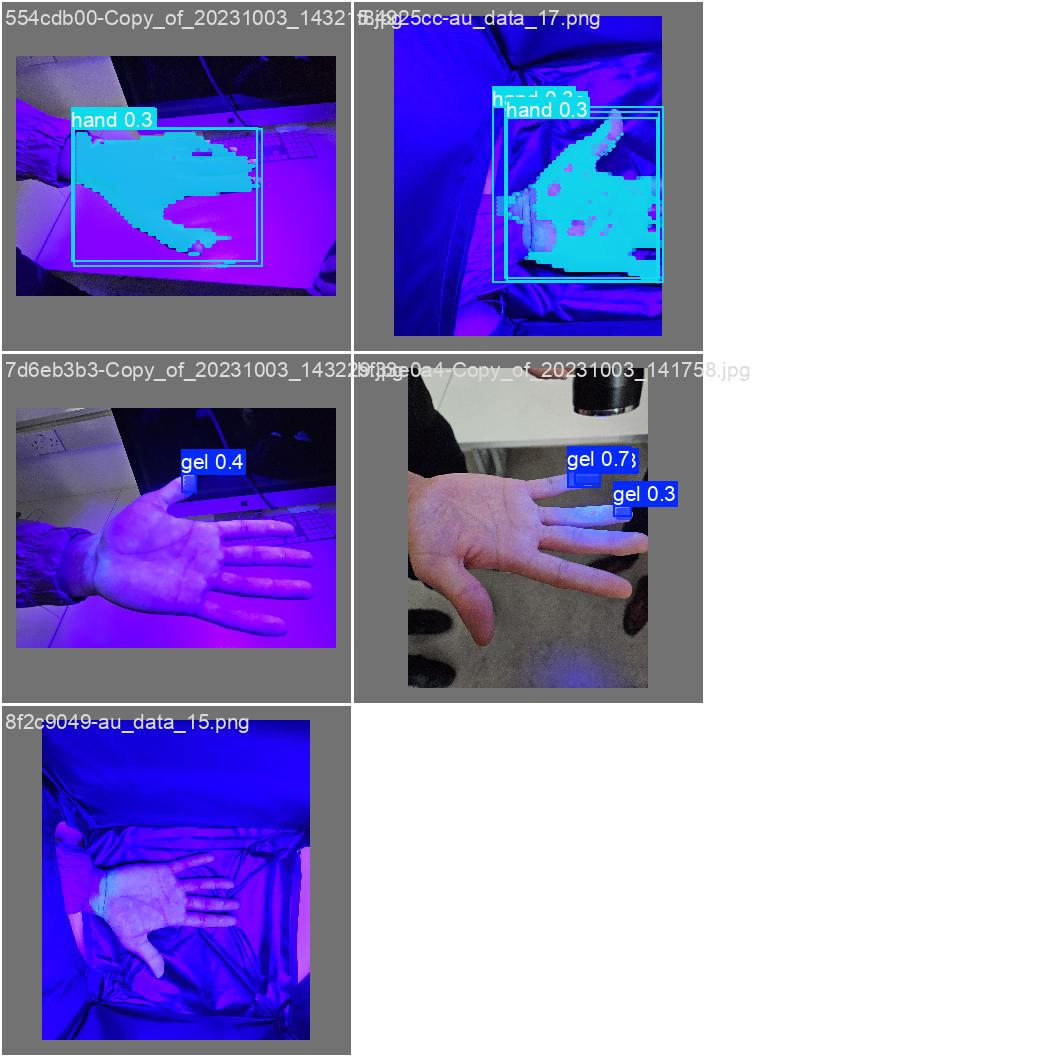

In [11]:
from IPython.display import display, Image
display(Image(filename="/content/runs/segment/val/val_batch0_pred.jpg"))

In [12]:
from ultralytics import YOLO
from pathlib import Path

MODEL = "/content/drive/MyDrive/hand_hygeine_project/best_split_fast.pt"
DATASET_DIR = "/content/drive/MyDrive/hand_hygeine_project/dataset_split"

model = YOLO(MODEL)

img_dir = Path(f"{DATASET_DIR}/images/val")
imgs = sorted([str(p) for p in img_dir.iterdir() if p.is_file()])

results = model.predict(
    source=imgs,
    imgsz=320,
    conf=0.2,   # higher = fewer duplicates
    iou=0.3,    # lower = remove overlaps more aggressively
    max_det=5,  # limit predictions per image
    save=False,
)
print("Done")


0: 320x320 2 hands, 49.6ms
1: 320x320 1 gel, 4 hands, 49.6ms
2: 320x320 1 hand, 49.6ms
3: 320x320 4 gels, 1 hand, 49.6ms
4: 320x320 1 gel, 3 hands, 49.6ms
Speed: 1.0ms preprocess, 49.6ms inference, 1.6ms postprocess per image at shape (1, 3, 320, 320)
Done


In [13]:
import csv, yaml
import numpy as np
from pathlib import Path
from ultralytics import YOLO

DATASET_DIR = "/content/drive/MyDrive/hand_hygeine_project/dataset_split"
MODEL_PATH = "/content/drive/MyDrive/hand_hygeine_project/best_split_fast.pt"
OUT_CSV = "/content/drive/MyDrive/hand_hygeine_project/gel_percent_results_val_dedup.csv"

names = yaml.safe_load(open(f"{DATASET_DIR}/data.yaml", "r"))["names"]
model = YOLO(MODEL_PATH)
model.model.names = names

img_dir = Path(f"{DATASET_DIR}/images/val")
imgs = sorted([str(p) for p in img_dir.iterdir() if p.is_file()])

rows = []
for r in model.predict(source=imgs, conf=0.2, iou=0.3, imgsz=320, save=False, verbose=False):
    gel_px = 0
    hand_areas = []

    if r.masks is not None:
        masks = r.masks.data.cpu().numpy()
        cls = r.boxes.cls.cpu().numpy().astype(int)
        for m, c in zip(masks, cls):
            area = int(m.sum())
            if c == 0:  # gel
                gel_px += area
            elif c == 1:  # hand
                hand_areas.append(area)

    hand_px = max(hand_areas) if hand_areas else 0
    gel_pct = (100.0 * gel_px / hand_px) if hand_px > 0 else 0.0

    rows.append([Path(r.path).name, gel_px, hand_px, gel_pct, len(hand_areas)])
    print(Path(r.path).name, "gel%:", round(gel_pct, 2), "hand_detections:", len(hand_areas))

with open(OUT_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["image", "gel_pixels_sum", "hand_pixels_largest", "gel_percent", "hand_detections"])
    w.writerows(rows)


image0.jpg gel%: 0.0 hand_detections: 2
image1.jpg gel%: 6.78 hand_detections: 5
image2.jpg gel%: 0.0 hand_detections: 1
image3.jpg gel%: 8.43 hand_detections: 2
image4.jpg gel%: 4.14 hand_detections: 3


In [14]:
import csv, yaml
from pathlib import Path
from ultralytics import YOLO

DATASET_DIR = "/content/drive/MyDrive/hand_hygeine_project/dataset_split"
MODEL_PATH = "/content/drive/MyDrive/hand_hygeine_project/best_split_fast.pt"
OUT_CSV = "/content/drive/MyDrive/hand_hygeine_project/gel_percent_results_val_dedup_conf01.csv"

names = yaml.safe_load(open(f"{DATASET_DIR}/data.yaml", "r"))["names"]
model = YOLO(MODEL_PATH)
model.model.names = names

img_dir = Path(f"{DATASET_DIR}/images/val")
imgs = sorted([str(p) for p in img_dir.iterdir() if p.is_file()])

rows = []
for r in model.predict(source=imgs, conf=0.1, iou=0.3, imgsz=320, save=False, verbose=False):
    gel_px = 0
    hand_areas = []

    if r.masks is not None:
        masks = r.masks.data.cpu().numpy()
        cls = r.boxes.cls.cpu().numpy().astype(int)
        for m, c in zip(masks, cls):
            area = int(m.sum())
            if c == 0:
                gel_px += area
            elif c == 1:
                hand_areas.append(area)

    hand_px = max(hand_areas) if hand_areas else 0
    gel_pct = (100.0 * gel_px / hand_px) if hand_px > 0 else 0.0
    rows.append([Path(r.path).name, gel_px, hand_px, gel_pct, len(hand_areas)])
    print(Path(r.path).name, "gel%:", round(gel_pct, 2), "hand_detections:", len(hand_areas))

with open(OUT_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["image", "gel_pixels_sum", "hand_pixels_largest", "gel_percent", "hand_detections"])
    w.writerows(rows)

print("Saved CSV:", OUT_CSV)

image0.jpg gel%: 1.94 hand_detections: 3
image1.jpg gel%: 6.78 hand_detections: 6
image2.jpg gel%: 16.03 hand_detections: 3
image3.jpg gel%: 16.71 hand_detections: 3
image4.jpg gel%: 22.61 hand_detections: 4
Saved CSV: /content/drive/MyDrive/hand_hygeine_project/gel_percent_results_val_dedup_conf01.csv


In [15]:
import csv, yaml
from pathlib import Path
from ultralytics import YOLO

DATASET_DIR = "/content/drive/MyDrive/hand_hygeine_project/dataset_split"
MODEL_PATH = "/content/drive/MyDrive/hand_hygeine_project/best_split_fast.pt"
OUT_CSV = "/content/drive/MyDrive/hand_hygeine_project/gel_percent_results_all_dedup_conf01.csv"

names = yaml.safe_load(open(f"{DATASET_DIR}/data.yaml", "r"))["names"]
model = YOLO(MODEL_PATH)
model.model.names = names

def iter_images(split):
    img_dir = Path(f"{DATASET_DIR}/images/{split}")
    return sorted([str(p) for p in img_dir.iterdir() if p.is_file()])

rows = []
for split in ["train", "val"]:
    imgs = iter_images(split)
    for r in model.predict(source=imgs, conf=0.1, iou=0.3, imgsz=320, save=False, verbose=False):
        gel_px = 0
        hand_areas = []

        if r.masks is not None:
            masks = r.masks.data.cpu().numpy()
            cls = r.boxes.cls.cpu().numpy().astype(int)
            for m, c in zip(masks, cls):
                area = int(m.sum())
                if c == 0:
                    gel_px += area
                elif c == 1:
                    hand_areas.append(area)

        hand_px = max(hand_areas) if hand_areas else 0
        gel_pct = (100.0 * gel_px / hand_px) if hand_px > 0 else 0.0
        rows.append([split, Path(r.path).name, gel_px, hand_px, gel_pct, len(hand_areas)])

with open(OUT_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["split", "image", "gel_pixels_sum", "hand_pixels_largest", "gel_percent", "hand_detections"])
    w.writerows(rows)

print("Saved CSV:", OUT_CSV)
print("Rows:", len(rows))

Saved CSV: /content/drive/MyDrive/hand_hygeine_project/gel_percent_results_all_dedup_conf01.csv
Rows: 26


In [16]:
import csv

IN_CSV  = "/content/drive/MyDrive/hand_hygeine_project/gel_percent_results_all_dedup_conf01.csv"
OUT_CSV = "/content/drive/MyDrive/hand_hygeine_project/gel_percent_results_all_labeled.csv"

def gel_level(p):
    if p < 5:
        return "none"
    elif p < 15:
        return "low"
    elif p < 30:
        return "medium"
    else:
        return "high"

rows = []
with open(IN_CSV, "r", newline="") as f:
    reader = csv.DictReader(f)
    for r in reader:
        p = float(r["gel_percent"])
        r["gel_level"] = gel_level(p)
        rows.append(r)

with open(OUT_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

print("Saved:", OUT_CSV)
print("Example rows:", rows[:3])

Saved: /content/drive/MyDrive/hand_hygeine_project/gel_percent_results_all_labeled.csv
Example rows: [{'split': 'train', 'image': 'image0.jpg', 'gel_pixels_sum': '3040', 'hand_pixels_largest': '28428', 'gel_percent': '10.693682285071057', 'hand_detections': '5', 'gel_level': 'low'}, {'split': 'train', 'image': 'image1.jpg', 'gel_pixels_sum': '3805', 'hand_pixels_largest': '24212', 'gel_percent': '15.715347761440608', 'hand_detections': '3', 'gel_level': 'medium'}, {'split': 'train', 'image': 'image2.jpg', 'gel_pixels_sum': '3025', 'hand_pixels_largest': '0', 'gel_percent': '0.0', 'hand_detections': '0', 'gel_level': 'none'}]


In [17]:
import csv

IN_CSV  = "/content/drive/MyDrive/hand_hygeine_project/gel_percent_results_all_labeled.csv"
OUT_CSV = "/content/drive/MyDrive/hand_hygeine_project/gel_percent_results_all_labeled_status.csv"

rows = []
with open(IN_CSV, "r", newline="") as f:
    reader = csv.DictReader(f)
    for r in reader:
        hand_px = int(float(r["hand_pixels_largest"]))
        r["status"] = "ok" if hand_px > 0 else "no_hand_detected"
        rows.append(r)

with open(OUT_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

print("Saved:", OUT_CSV)
print("No-hand rows:", sum(1 for r in rows if r["status"] != "ok"))

Saved: /content/drive/MyDrive/hand_hygeine_project/gel_percent_results_all_labeled_status.csv
No-hand rows: 9


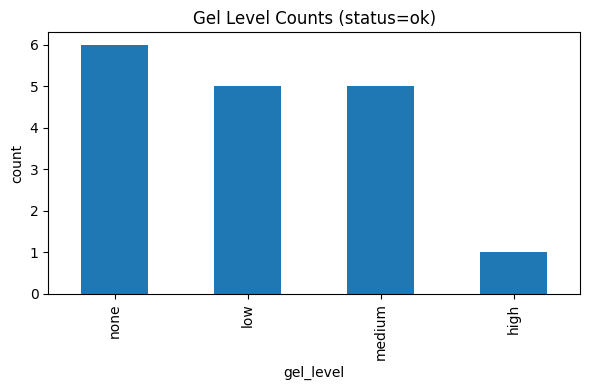

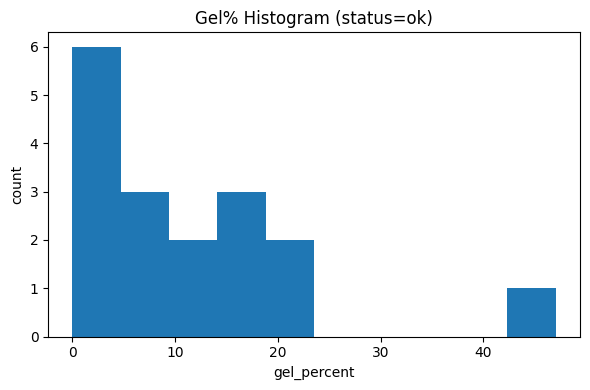

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "/content/drive/MyDrive/hand_hygeine_project/gel_percent_results_all_labeled_status.csv"
df = pd.read_csv(CSV_PATH)

df_ok = df[df["status"] == "ok"].copy()
df_ok["gel_percent"] = pd.to_numeric(df_ok["gel_percent"], errors="coerce")

plt.figure(figsize=(6,4))
df_ok["gel_level"].value_counts().reindex(["none","low","medium","high"]).plot(kind="bar")
plt.title("Gel Level Counts (status=ok)")
plt.xlabel("gel_level")
plt.ylabel("count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
df_ok["gel_percent"].plot(kind="hist", bins=10)
plt.title("Gel% Histogram (status=ok)")
plt.xlabel("gel_percent")
plt.ylabel("count")
plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

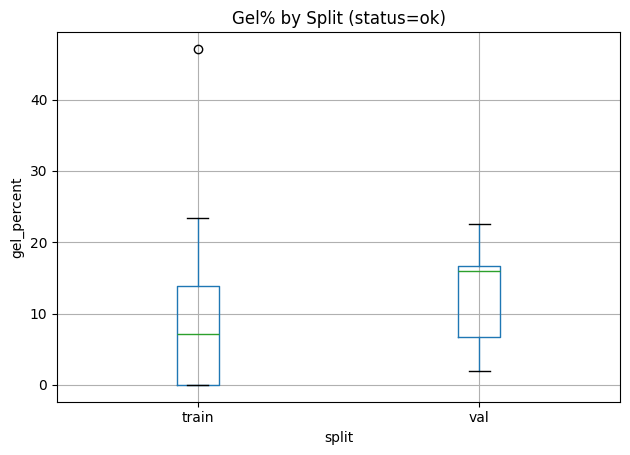

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "/content/drive/MyDrive/hand_hygeine_project/gel_percent_results_all_labeled_status.csv"
df = pd.read_csv(CSV_PATH)

df_ok = df[df["status"] == "ok"].copy()
df_ok["gel_percent"] = pd.to_numeric(df_ok["gel_percent"], errors="coerce")

plt.figure(figsize=(6,4))
df_ok.boxplot(column="gel_percent", by="split")
plt.title("Gel% by Split (status=ok)")
plt.suptitle("")
plt.xlabel("split")
plt.ylabel("gel_percent")
plt.tight_layout()
plt.show()